# EEG_GNN_temporal_baseline_spatial_graph_FIXED

Versione corretta e robusta della baseline **spatio-temporal GNN**.

## Cosa cambia rispetto alla versione precedente
Qui **non** usiamo `torch_geometric.DataLoader` per batchare direttamente `x_seq`, perché PyG concatena i tensori e rompe la struttura `(B, W, N, F)`.

Invece facciamo così:

- dataset PyTorch standard
- ogni item = un trial temporale con:
  - `x_seq`: `(5, 59, 40)`
  - `y`
  - metadata
- `edge_index` spaziale statico tenuto separato
- GCN applicata finestra per finestra
- aggregazione temporale con:
  - `mean`
  - oppure `GRU`

## Obiettivi
1. Costruire il grafo spaziale statico
2. Creare un dataset temporale robusto
3. Allenare:
   - **GCN + temporal mean**
   - **GCN + GRU**
4. Valutare in:
   - subject-specific
   - subject-independent
5. Visualizzare training curves ed embedding

Data: 2026-03-07


In [ ]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True        # False → 110 parole originali
CLUSTER_SCHEME = "sem5"      # "sem5" | "pos4" | "ward4" | "ward5"
#                              (ignorato se USE_CLUSTERS = False)
# ═══════════════════════════════════════════════════════════

import sys
from pathlib import Path
import numpy as np

_project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
_interim_dir  = _project_root / "data" / "interim"
sys.path.insert(0, str(_project_root / "scripts"))
from utils import load_label_scheme

_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, _interim_dir)

print(f"Schema  : {'clustering ' + CLUSTER_SCHEME if USE_CLUSTERS else '110 parole originali'}")
print(f"Classi  : {N_CLASSES}  |  Chance level: {100/N_CLASSES:.1f}%")
if USE_CLUSTERS:
    for cid, cname in cluster_names.items():
        n = sum(1 for v in labelid2cluster.values() if v == cid)
        print(f"  {cid} — {cname}: {n} parole")

def remap_y(y_raw):
    """Rimappa label_id (0-109) → cluster_id in base al toggle attivo."""
    import torch
    if isinstance(y_raw, torch.Tensor):
        return torch.tensor([labelid2cluster[int(v)] for v in y_raw.view(-1)],
                             dtype=torch.long).view(y_raw.shape)
    out = np.array([labelid2cluster[int(v)] for v in np.asarray(y_raw).ravel()], dtype=np.int64)
    return out.reshape(np.asarray(y_raw).shape)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import mne

from collections import defaultdict
from sklearn.metrics import pairwise_distances, accuracy_score, balanced_accuracy_score
from sklearn.decomposition import PCA

from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool


## Paths and setup


In [2]:
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

time_dir = project_root / "data" / "processed" / "subject_tensors" / "subject_tensors_time"
assert time_dir.exists(), f"Missing {time_dir}"

files = sorted(time_dir.glob("subject_*.pt"))
print("num subject files:", len(files))
assert len(files) > 0, "No time subject tensors found"

sample_obj = torch.load(files[0], map_location="cpu")
ch_names = sample_obj["ch_names"]
feature_cols = sample_obj["feature_cols"]

print("num channels:", len(ch_names))
print("num features:", len(feature_cols))
print("num windows:", sample_obj["X"].shape[1])
print("first channels:", ch_names[:10])


num subject files: 74
num channels: 59
num features: 40
num windows: 5
first channels: ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1']


## Read montage and extract coordinates


In [3]:
eloc_path = project_root / "src" / "io" / "ebneuro.locs"
assert eloc_path.exists(), f"Missing {eloc_path}"

montage = mne.channels.read_custom_montage(str(eloc_path))
pos_dict = montage.get_positions()["ch_pos"]

coords = np.stack([pos_dict[ch] for ch in ch_names], axis=0)
xy = coords[:, :2]
print("coords shape:", coords.shape)


coords shape: (59, 3)


## Build static spatial graph from distances


In [4]:
K = 4

def build_knn_edge_index(coords, k=4, make_undirected=True):
    D = pairwise_distances(coords)
    n = len(coords)
    edges = set()

    for i in range(n):
        nn = np.argsort(D[i])[1:k+1]
        for j in nn:
            edges.add((i, j))
            if make_undirected:
                edges.add((j, i))

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    return edge_index, D

edge_index, D = build_knn_edge_index(coords, k=K, make_undirected=True)
edge_index = edge_index.long()

print("edge_index shape:", edge_index.shape)
print("num directed edges:", edge_index.shape[1])


edge_index shape: torch.Size([2, 258])
num directed edges: 258


## Plot the spatial EEG graph


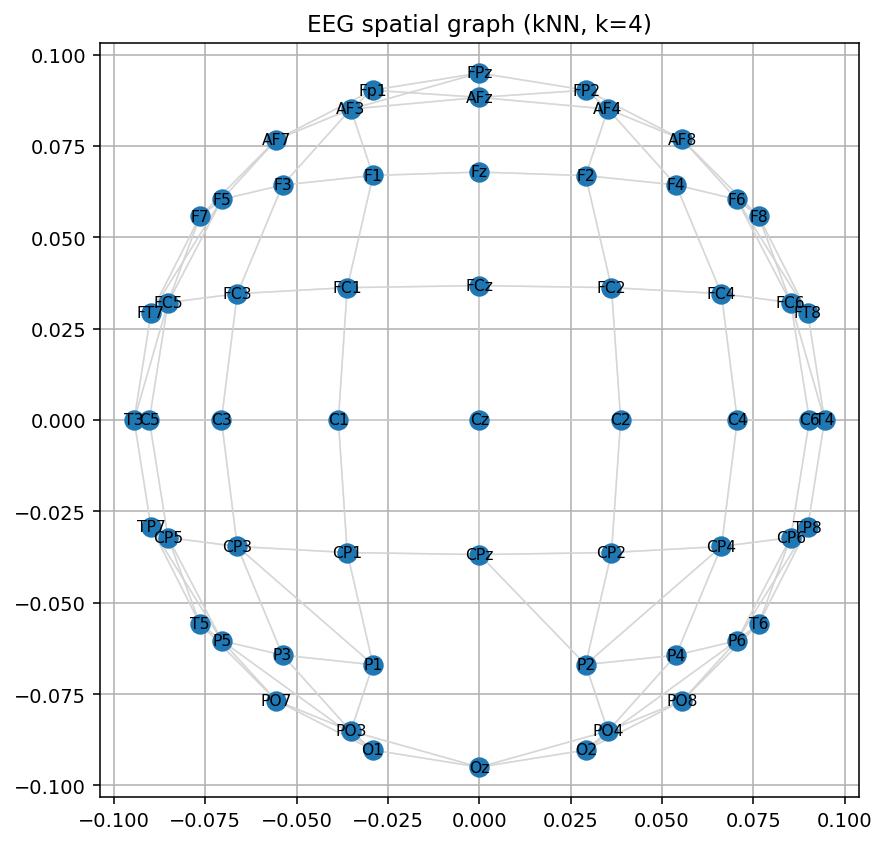

In [5]:
ei = edge_index.numpy()

plt.figure(figsize=(7, 7), dpi=140)

for s, t in ei.T:
    plt.plot([xy[s, 0], xy[t, 0]], [xy[s, 1], xy[t, 1]], color="lightgray", linewidth=0.8, alpha=0.7)

plt.scatter(xy[:, 0], xy[:, 1], s=90, zorder=3)

for i, ch in enumerate(ch_names):
    plt.text(xy[i, 0], xy[i, 1], ch, fontsize=8, ha="center", va="center")

plt.title(f"EEG spatial graph (kNN, k={K})")
plt.axis("equal")
plt.grid(True)
plt.show()


trial_items = []

for p in files:
    obj = torch.load(p, map_location="cpu")

    X = obj["X"].float()           # (n_trials, 5, 59, 40)
    y = obj["y"].long()
    y = remap_y(y)
    subject_id = obj["subject_id"].long()
    session_id = obj["session_id"].long()
    epoch_idx = obj["epoch_idx"].long()

    for i in range(X.shape[0]):
        trial_items.append({
            "x_seq": X[i].clone(),                    # (5, 59, 40)
            "y": int(y[i].item()),
            "subject_id": int(subject_id[i].item()),
            "session_id": int(session_id[i].item()),
            "epoch_idx": int(epoch_idx[i].item()),
        })

print("num temporal trial items:", len(trial_items))
print("example x_seq shape:", trial_items[0]["x_seq"].shape)

In [6]:
trial_items = []

for p in files:
    obj = torch.load(p, map_location="cpu")

    X = obj["X"].float()           # (n_trials, 5, 59, 40)
    y = obj["y"].long()
    subject_id = obj["subject_id"].long()
    session_id = obj["session_id"].long()
    epoch_idx = obj["epoch_idx"].long()

    for i in range(X.shape[0]):
        trial_items.append({
            "x_seq": X[i].clone(),                    # (5, 59, 40)
            "y": int(y[i].item()),
            "subject_id": int(subject_id[i].item()),
            "session_id": int(session_id[i].item()),
            "epoch_idx": int(epoch_idx[i].item()),
        })

print("num temporal trial items:", len(trial_items))
print("example x_seq shape:", trial_items[0]["x_seq"].shape)


num temporal trial items: 38926
example x_seq shape: torch.Size([5, 59, 40])


## Example node feature map for one trial / one window


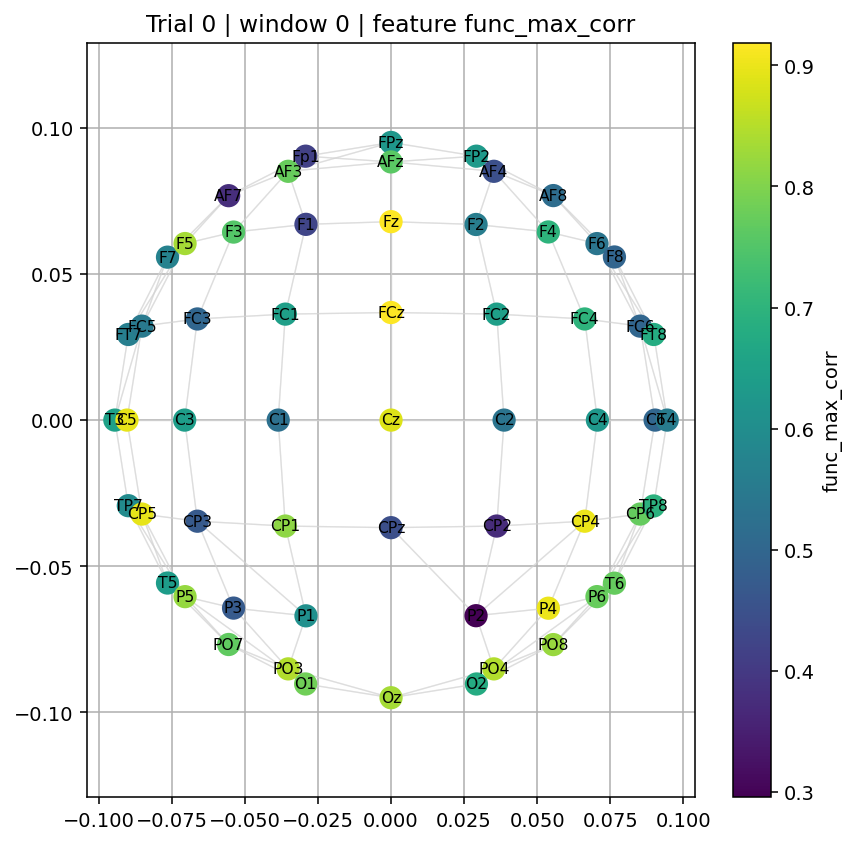

In [7]:
TRIAL_IDX = 0
WINDOW_IDX = 0
FEATURE_IDX = 0

vals = trial_items[TRIAL_IDX]["x_seq"][WINDOW_IDX, :, FEATURE_IDX].numpy()

plt.figure(figsize=(7, 7), dpi=140)

for s, t in ei.T:
    plt.plot([xy[s, 0], xy[t, 0]], [xy[s, 1], xy[t, 1]], color="lightgray", linewidth=0.7, alpha=0.5)

sc = plt.scatter(xy[:, 0], xy[:, 1], c=vals, s=120, zorder=3)

for i, ch in enumerate(ch_names):
    plt.text(xy[i, 0], xy[i, 1], ch, fontsize=8, ha="center", va="center")

plt.colorbar(sc, label=feature_cols[FEATURE_IDX])
plt.title(f"Trial {TRIAL_IDX} | window {WINDOW_IDX} | feature {feature_cols[FEATURE_IDX]}")
plt.axis("equal")
plt.grid(True)
plt.show()


## Split utilities


In [8]:
def get_subject_specific_split(items, subject_id, seed=42):
    rng = np.random.RandomState(seed)

    subj_items = [g for g in items if g["subject_id"] == subject_id]
    labels = np.array([g["y"] for g in subj_items])

    class_to_idx = defaultdict(list)
    for i, yy in enumerate(labels):
        class_to_idx[int(yy)].append(i)

    idx_train, idx_val, idx_test = [], [], []

    for cls, idxs in class_to_idx.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)

        if len(idxs) < 5:
            continue

        idx_train.extend(idxs[:3])
        idx_val.extend(idxs[3:4])
        idx_test.extend(idxs[4:5])

    train_items = [subj_items[i] for i in idx_train]
    val_items   = [subj_items[i] for i in idx_val]
    test_items  = [subj_items[i] for i in idx_test]

    return train_items, val_items, test_items


def get_subject_independent_split(items, test_frac=0.2, val_frac=0.2, seed=42):
    rng = np.random.RandomState(seed)

    subj_ids = sorted(list({g["subject_id"] for g in items}))
    rng.shuffle(subj_ids)

    n_test = max(1, int(round(len(subj_ids) * test_frac)))
    test_subjects = set(subj_ids[:n_test])

    remaining = subj_ids[n_test:]
    n_val = max(1, int(round(len(remaining) * val_frac)))
    val_subjects = set(remaining[:n_val])
    train_subjects = set(remaining[n_val:])

    train_items = [g for g in items if g["subject_id"] in train_subjects]
    val_items   = [g for g in items if g["subject_id"] in val_subjects]
    test_items  = [g for g in items if g["subject_id"] in test_subjects]

    return train_items, val_items, test_items, train_subjects, val_subjects, test_subjects


## Dataset and collate


In [9]:
class TemporalEEGDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        return {
            "x_seq": item["x_seq"].float(),                   # (W, N, F)
            "y": torch.tensor(item["y"], dtype=torch.long),
            "subject_id": torch.tensor(item["subject_id"], dtype=torch.long),
            "session_id": torch.tensor(item["session_id"], dtype=torch.long),
            "epoch_idx": torch.tensor(item["epoch_idx"], dtype=torch.long),
        }

def collate_temporal(batch):
    return {
        "x_seq": torch.stack([b["x_seq"] for b in batch], dim=0),      # (B, W, N, F)
        "y": torch.stack([b["y"] for b in batch], dim=0),              # (B,)
        "subject_id": torch.stack([b["subject_id"] for b in batch], dim=0),
        "session_id": torch.stack([b["session_id"] for b in batch], dim=0),
        "epoch_idx": torch.stack([b["epoch_idx"] for b in batch], dim=0),
    }


## Temporal GNN models


In [10]:
class GraphEncoder(nn.Module):
    def __init__(self, in_dim=40, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return x


class TemporalMeanGCN(nn.Module):
    def __init__(self, in_dim=40, hidden_dim=64, n_classes=110, dropout=0.3):
        super().__init__()
        self.encoder = GraphEncoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, n_classes)
        self.dropout = dropout

    def forward(self, x_seq, edge_index, return_embedding=False):
        # x_seq: (B, W, N, F)
        B, W, N, Fdim = x_seq.shape
        graph_embs = []

        base_batch = torch.arange(B, device=x_seq.device).repeat_interleave(N)

        for w in range(W):
            xw = x_seq[:, w, :, :].reshape(B * N, Fdim)          # (B*N, F)
            ew = self.encoder(xw, edge_index)                    # (B*N, H)
            gw = global_mean_pool(ew, base_batch)                # (B, H)
            graph_embs.append(gw)

        H = torch.stack(graph_embs, dim=1)                       # (B, W, H)
        emb = H.mean(dim=1)                                      # (B, H)

        x = self.lin1(emb)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        logits = self.lin2(x)

        if return_embedding:
            return logits, emb
        return logits


class TemporalGRUGCN(nn.Module):
    def __init__(self, in_dim=40, hidden_dim=64, n_classes=110, dropout=0.3):
        super().__init__()
        self.encoder = GraphEncoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout)
        self.gru = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, n_classes)
        self.dropout = dropout

    def forward(self, x_seq, edge_index, return_embedding=False):
        # x_seq: (B, W, N, F)
        B, W, N, Fdim = x_seq.shape
        graph_embs = []

        base_batch = torch.arange(B, device=x_seq.device).repeat_interleave(N)

        for w in range(W):
            xw = x_seq[:, w, :, :].reshape(B * N, Fdim)
            ew = self.encoder(xw, edge_index)
            gw = global_mean_pool(ew, base_batch)
            graph_embs.append(gw)

        H = torch.stack(graph_embs, dim=1)                       # (B, W, H)
        _, h_last = self.gru(H)
        emb = h_last[-1]                                         # (B, H)

        x = self.lin1(emb)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        logits = self.lin2(x)

        if return_embedding:
            return logits, emb
        return logits


## Training and evaluation helpers


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

edge_index_device = edge_index.to(device)

def eval_temporal_model(model, loader, edge_index, device="cpu"):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for batch in loader:
            x_seq = batch["x_seq"].to(device)
            y = batch["y"].to(device)

            logits = model(x_seq, edge_index)
            pred = logits.argmax(dim=1).cpu().numpy()

            preds.extend(pred.tolist())
            ys.extend(y.cpu().numpy().tolist())

    return {
        "acc": accuracy_score(ys, preds),
        "bal_acc": balanced_accuracy_score(ys, preds),
        "y_true": np.array(ys),
        "y_pred": np.array(preds),
    }


def extract_temporal_embeddings(model, loader, edge_index, device="cpu"):
    model.eval()
    embs, ys, subs = [], [], []

    with torch.no_grad():
        for batch in loader:
            x_seq = batch["x_seq"].to(device)
            y = batch["y"].to(device)
            subject_id = batch["subject_id"].to(device)

            logits, emb = model(x_seq, edge_index, return_embedding=True)
            embs.append(emb.cpu().numpy())
            ys.append(y.cpu().numpy())
            subs.append(subject_id.cpu().numpy())

    return np.concatenate(embs), np.concatenate(ys), np.concatenate(subs)


def train_temporal_model(model, train_items, val_items, edge_index, lr=1e-3, wd=1e-4,
                         batch_size=64, max_epochs=100, patience=10, device="cpu"):
    train_ds = TemporalEEGDataset(train_items)
    val_ds = TemporalEEGDataset(val_items)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_temporal)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_temporal)

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_state = None
    best_val = -1.0
    history = []

    wait = 0
    for epoch in range(max_epochs):
        model.train()
        losses = []

        for batch in train_loader:
            x_seq = batch["x_seq"].to(device)
            y = batch["y"].to(device)

            opt.zero_grad()
            logits = model(x_seq, edge_index)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            losses.append(float(loss.item()))

        val_res = eval_temporal_model(model, val_loader, edge_index, device=device)
        mean_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan
        history.append({
            "epoch": epoch + 1,
            "train_loss": mean_loss,
            "val_acc": val_res["acc"],
            "val_bal_acc": val_res["bal_acc"],
        })

        if val_res["bal_acc"] > best_val:
            best_val = val_res["bal_acc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    history = pd.DataFrame(history)
    return model, history


device: cpu


## Choose model type


In [12]:
MODEL_TYPE = "gru"   # options: "mean", "gru"

def make_model(model_type="gru", hidden_dim=64, n_classes=110):
    if model_type == "mean":
        return TemporalMeanGCN(in_dim=40, hidden_dim=hidden_dim, n_classes=n_classes)
    elif model_type == "gru":
        return TemporalGRUGCN(in_dim=40, hidden_dim=hidden_dim, n_classes=n_classes)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")


SUBJECT_ID = 10

train_items, val_items, test_items = get_subject_specific_split(trial_items, SUBJECT_ID, seed=42)

print("subject:", SUBJECT_ID)
print("train:", len(train_items))
print("val  :", len(val_items))
print("test :", len(test_items))

model_ss = make_model(MODEL_TYPE, hidden_dim=64, n_classes=N_CLASSES)
model_ss, hist_ss = train_temporal_model(
    model_ss,
    train_items,
    val_items,
    edge_index=edge_index_device,
    lr=1e-3,
    batch_size=64,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(TemporalEEGDataset(val_items), batch_size=64, shuffle=False, collate_fn=collate_temporal)
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=64, shuffle=False, collate_fn=collate_temporal)

val_res_ss = eval_temporal_model(model_ss, val_loader, edge_index_device, device=device)
test_res_ss = eval_temporal_model(model_ss, test_loader, edge_index_device, device=device)

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-specific ===")
print("val acc     :", val_res_ss["acc"])
print("val bal_acc :", val_res_ss["bal_acc"])
print("test acc    :", test_res_ss["acc"])
print("test bal_acc:", test_res_ss["bal_acc"])

In [13]:
SUBJECT_ID = 10

train_items, val_items, test_items = get_subject_specific_split(trial_items, SUBJECT_ID, seed=42)

print("subject:", SUBJECT_ID)
print("train:", len(train_items))
print("val  :", len(val_items))
print("test :", len(test_items))

model_ss = make_model(MODEL_TYPE, hidden_dim=64, n_classes=110)
model_ss, hist_ss = train_temporal_model(
    model_ss,
    train_items,
    val_items,
    edge_index=edge_index_device,
    lr=1e-3,
    batch_size=64,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(TemporalEEGDataset(val_items), batch_size=64, shuffle=False, collate_fn=collate_temporal)
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=64, shuffle=False, collate_fn=collate_temporal)

val_res_ss = eval_temporal_model(model_ss, val_loader, edge_index_device, device=device)
test_res_ss = eval_temporal_model(model_ss, test_loader, edge_index_device, device=device)

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-specific ===")
print("val acc     :", val_res_ss["acc"])
print("val bal_acc :", val_res_ss["bal_acc"])
print("test acc    :", test_res_ss["acc"])
print("test bal_acc:", test_res_ss["bal_acc"])


subject: 10
train: 330
val  : 110
test : 110

=== Temporal GCN (gru) | subject-specific ===
val acc     : 0.01818181818181818
val bal_acc : 0.01818181818181818
test acc    : 0.00909090909090909
test bal_acc: 0.00909090909090909


## Plot training history — subject-specific


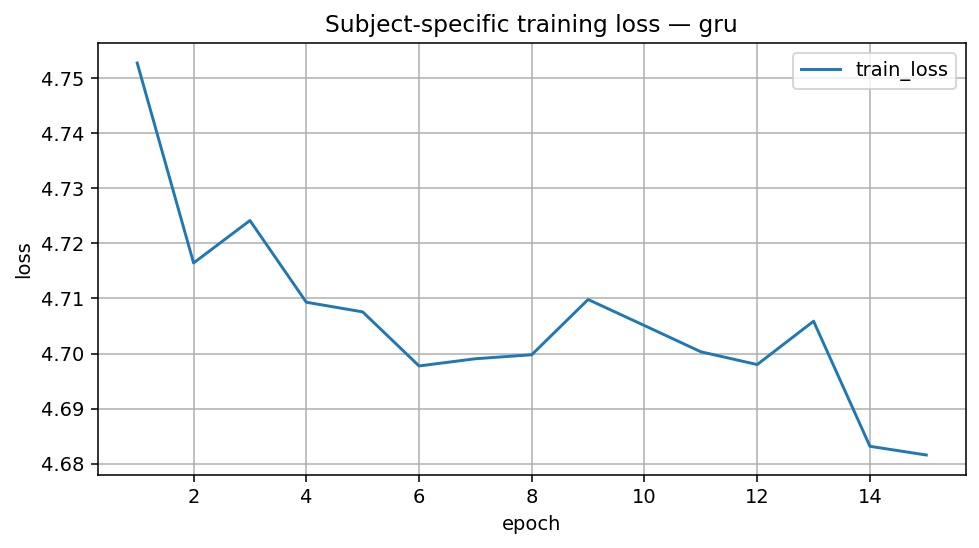

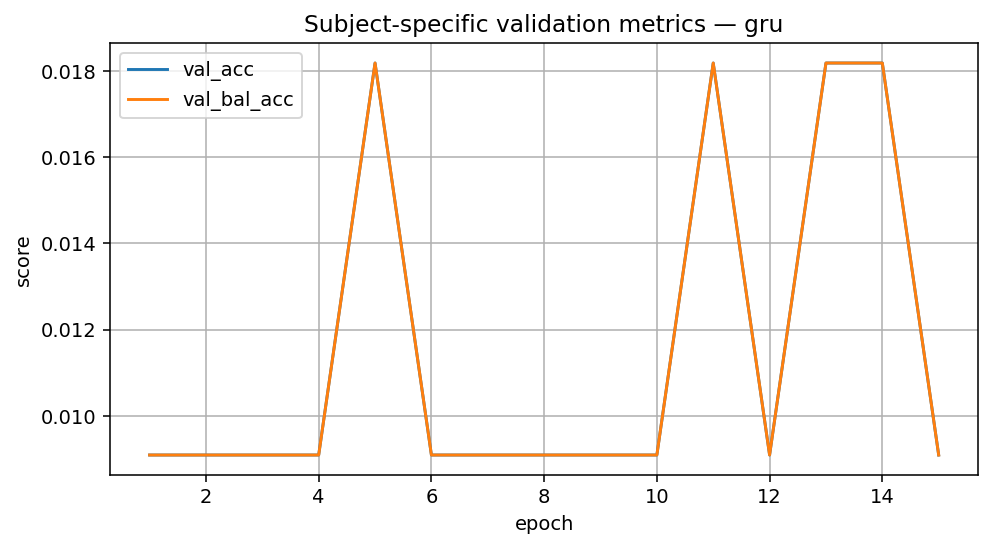

In [14]:
plt.figure(figsize=(8,4), dpi=140)
plt.plot(hist_ss["epoch"], hist_ss["train_loss"], label="train_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Subject-specific training loss — {MODEL_TYPE}")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4), dpi=140)
plt.plot(hist_ss["epoch"], hist_ss["val_acc"], label="val_acc")
plt.plot(hist_ss["epoch"], hist_ss["val_bal_acc"], label="val_bal_acc")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title(f"Subject-specific validation metrics — {MODEL_TYPE}")
plt.grid(True)
plt.legend()
plt.show()


## Embeddings — subject-specific (PCA)


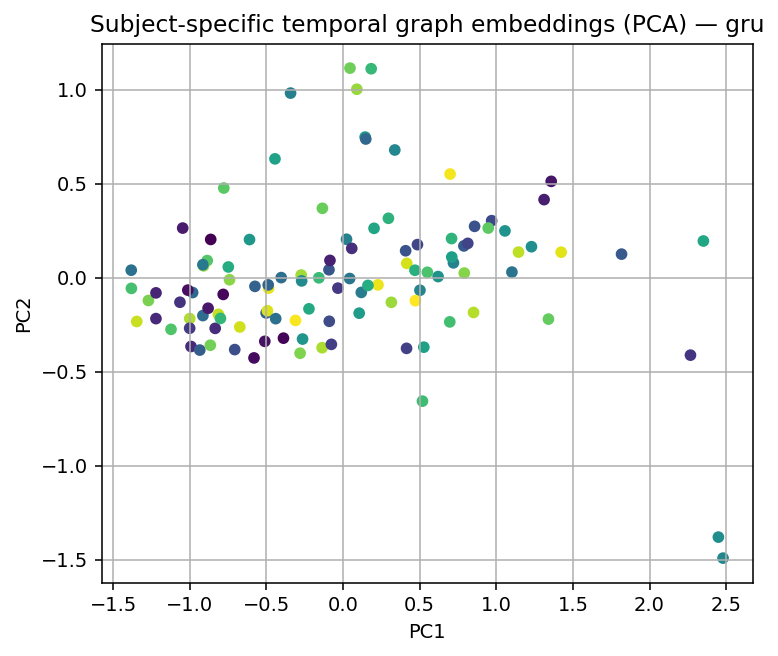

In [15]:
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=64, shuffle=False, collate_fn=collate_temporal)
emb_ss, y_ss, subj_ss = extract_temporal_embeddings(model_ss, test_loader, edge_index_device, device=device)

if emb_ss.shape[0] >= 2:
    X_pca = PCA(n_components=2).fit_transform(emb_ss)

    plt.figure(figsize=(6,5), dpi=140)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y_ss, s=25)
    plt.title(f"Subject-specific temporal graph embeddings (PCA) — {MODEL_TYPE}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
else:
    print("Not enough points for PCA")


train_items, val_items, test_items, tr_subj, va_subj, te_subj = get_subject_independent_split(
    trial_items, test_frac=0.2, val_frac=0.2, seed=42
)

print("train subjects:", len(tr_subj))
print("val subjects  :", len(va_subj))
print("test subjects :", len(te_subj))
print("train trials   :", len(train_items))
print("val trials     :", len(val_items))
print("test trials    :", len(test_items))

model_si = make_model(MODEL_TYPE, hidden_dim=64, n_classes=N_CLASSES)
model_si, hist_si = train_temporal_model(
    model_si,
    train_items,
    val_items,
    edge_index=edge_index_device,
    lr=1e-3,
    batch_size=128,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(TemporalEEGDataset(val_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)

val_res_si = eval_temporal_model(model_si, val_loader, edge_index_device, device=device)
test_res_si = eval_temporal_model(model_si, test_loader, edge_index_device, device=device)

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-independent ===")
print("val acc     :", val_res_si["acc"])
print("val bal_acc :", val_res_si["bal_acc"])
print("test acc    :", test_res_si["acc"])
print("test bal_acc:", test_res_si["bal_acc"])

In [16]:
train_items, val_items, test_items, tr_subj, va_subj, te_subj = get_subject_independent_split(
    trial_items, test_frac=0.2, val_frac=0.2, seed=42
)

print("train subjects:", len(tr_subj))
print("val subjects  :", len(va_subj))
print("test subjects :", len(te_subj))
print("train trials   :", len(train_items))
print("val trials     :", len(val_items))
print("test trials    :", len(test_items))

model_si = make_model(MODEL_TYPE, hidden_dim=64, n_classes=110)
model_si, hist_si = train_temporal_model(
    model_si,
    train_items,
    val_items,
    edge_index=edge_index_device,
    lr=1e-3,
    batch_size=128,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(TemporalEEGDataset(val_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)

val_res_si = eval_temporal_model(model_si, val_loader, edge_index_device, device=device)
test_res_si = eval_temporal_model(model_si, test_loader, edge_index_device, device=device)

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-independent ===")
print("val acc     :", val_res_si["acc"])
print("val bal_acc :", val_res_si["bal_acc"])
print("test acc    :", test_res_si["acc"])
print("test bal_acc:", test_res_si["bal_acc"])


train subjects: 47
val subjects  : 12
test subjects : 15
train trials   : 24900
val trials     : 6490
test trials    : 7536

=== Temporal GCN (gru) | subject-independent ===
val acc     : 0.010477657935285054
val bal_acc : 0.010477657935285054
test acc    : 0.009952229299363057
test bal_acc: 0.010001550027125475


## Plot training history — subject-independent


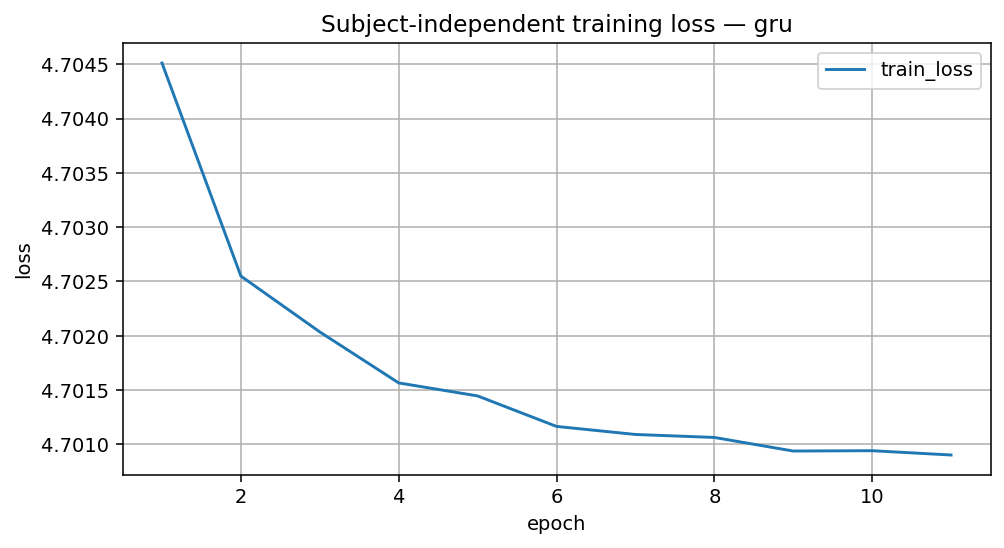

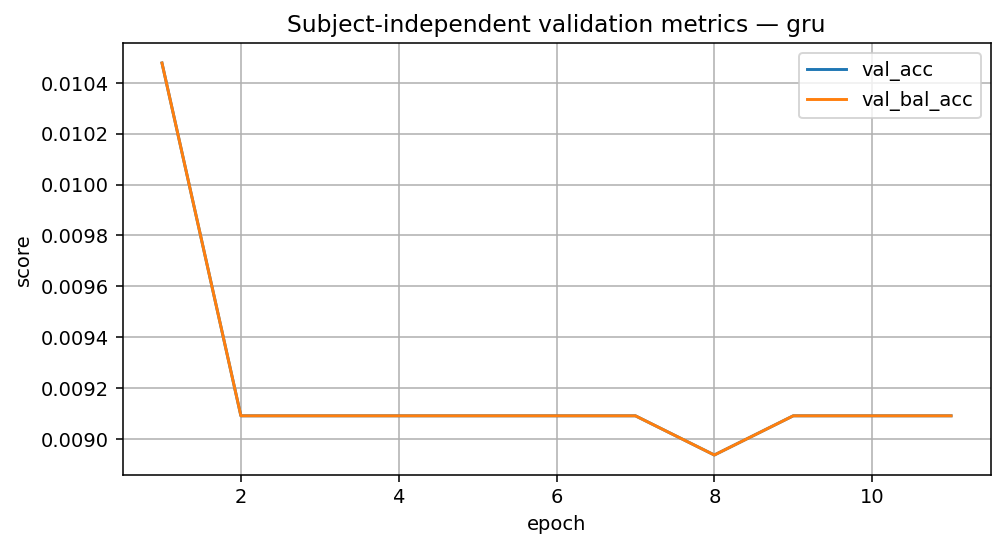

In [17]:
plt.figure(figsize=(8,4), dpi=140)
plt.plot(hist_si["epoch"], hist_si["train_loss"], label="train_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Subject-independent training loss — {MODEL_TYPE}")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4), dpi=140)
plt.plot(hist_si["epoch"], hist_si["val_acc"], label="val_acc")
plt.plot(hist_si["epoch"], hist_si["val_bal_acc"], label="val_bal_acc")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title(f"Subject-independent validation metrics — {MODEL_TYPE}")
plt.grid(True)
plt.legend()
plt.show()


## Embeddings — subject-independent (PCA)


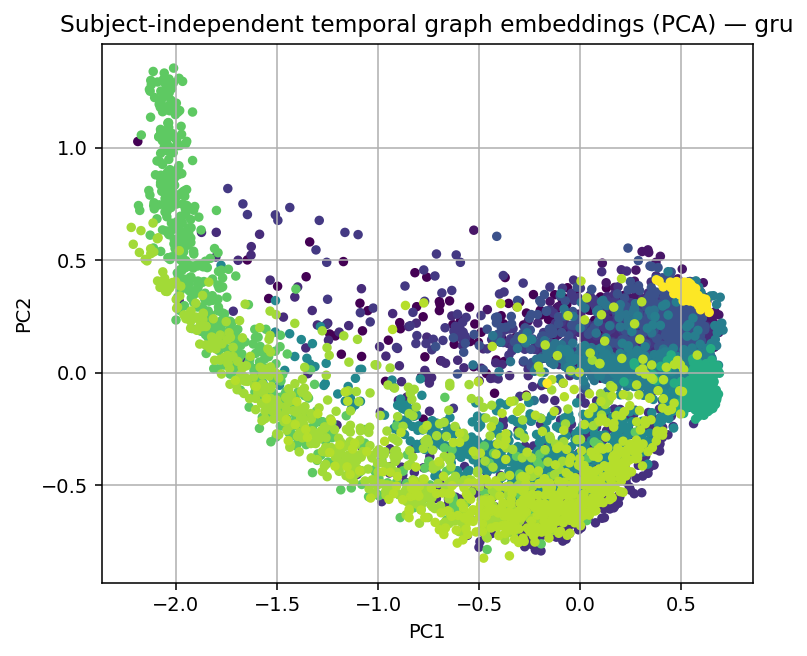

In [18]:
test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)
emb_si, y_si, subj_si = extract_temporal_embeddings(model_si, test_loader, edge_index_device, device=device)

if emb_si.shape[0] >= 2:
    X_pca = PCA(n_components=2).fit_transform(emb_si)

    plt.figure(figsize=(6,5), dpi=140)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=subj_si, s=15)
    plt.title(f"Subject-independent temporal graph embeddings (PCA) — {MODEL_TYPE}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
else:
    print("Not enough points for PCA")


seeds = [0, 1, 2, 3, 4]
accs, baccs = [], []

for seed in seeds:
    train_items, val_items, test_items, *_ = get_subject_independent_split(
        trial_items, test_frac=0.2, val_frac=0.2, seed=seed
    )

    model_tmp = make_model(MODEL_TYPE, hidden_dim=64, n_classes=N_CLASSES)
    model_tmp, hist_tmp = train_temporal_model(
        model_tmp,
        train_items,
        val_items,
        edge_index=edge_index_device,
        lr=1e-3,
        batch_size=128,
        max_epochs=100,
        patience=10,
        device=device
    )

    test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)
    res = eval_temporal_model(model_tmp, test_loader, edge_index_device, device=device)

    accs.append(res["acc"])
    baccs.append(res["bal_acc"])
    print(f"seed={seed} | acc={res['acc']:.4f} | bal_acc={res['bal_acc']:.4f}")

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-independent summary ===")
print("acc    :", np.mean(accs), "±", np.std(accs))
print("bal_acc:", np.mean(baccs), "±", np.std(baccs))

In [19]:
seeds = [0, 1, 2, 3, 4]
accs, baccs = [], []

for seed in seeds:
    train_items, val_items, test_items, *_ = get_subject_independent_split(
        trial_items, test_frac=0.2, val_frac=0.2, seed=seed
    )

    model_tmp = make_model(MODEL_TYPE, hidden_dim=64, n_classes=110)
    model_tmp, hist_tmp = train_temporal_model(
        model_tmp,
        train_items,
        val_items,
        edge_index=edge_index_device,
        lr=1e-3,
        batch_size=128,
        max_epochs=100,
        patience=10,
        device=device
    )

    test_loader = DataLoader(TemporalEEGDataset(test_items), batch_size=128, shuffle=False, collate_fn=collate_temporal)
    res = eval_temporal_model(model_tmp, test_loader, edge_index_device, device=device)

    accs.append(res["acc"])
    baccs.append(res["bal_acc"])
    print(f"seed={seed} | acc={res['acc']:.4f} | bal_acc={res['bal_acc']:.4f}")

print(f"\n=== Temporal GCN ({MODEL_TYPE}) | subject-independent summary ===")
print("acc    :", np.mean(accs), "±", np.std(accs))
print("bal_acc:", np.mean(baccs), "±", np.std(baccs))


seed=0 | acc=0.0088 | bal_acc=0.0087


KeyboardInterrupt: 